Week 2 Assignment

*  Dataset : Tesla E-A Deliveries and Production data (2015-2025)
*  Goal : Build an end-to-end ML pipeline on sales/price covering



Stpe 1 - Load Datadet and Intial Inspection


*   In this step, we load the dataset and perform an initial inspection to understand its structure, dimensions, data types, and overall quality before preprocessing and analysis.



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from google.colab import drive
drive.mount('/content/drive')
path ='/content/drive/My Drive/Colab Notebooks/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(path)

Mounted at /content/drive


In [15]:
#Basic inspection
print(f"Dataset Shape:", {df.shape})
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: {(2640, 12)}

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [16]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [17]:
print("Summary Statistics:")
display(df.describe(include='all'))

Summary Statistics:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


Intial Observation

*   The dataset contains Tesla Production and delivery related information.
*   Initial inspection helps identify feature names, data types, and potential preprocessing requirements.
*   Understanding the dataset structure is important before performing EDA and machine learning modeling.
*   The dataset contains 2640 records and 12 features with no missing values.
*   Summary statistics show that Tesla deliveries, production units, prices and charging infrastructure vary.









Step 2 : Data Quality Assessment and Cleaning


*   In this step, we evaluate the dataset for missing values, duplicate records and inconsistencies to ensure the data is clean and suitable for analysis and machine learning modeling.


In [18]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [19]:
print("Duplicate Rows:")
df.duplicated().sum()

Duplicate Rows:


np.int64(0)

Observations

*   No missing values were found in any column.
*   No duplicate records were detected.
*   The dataset is clean and does not require imutation or duplictate removal.
*   The data is ready for exploratory data analysis and feature engineering.





In [20]:
for col in ['Region', 'Model', 'Source_Type']:
  print(f"\n{col}")
  print(df[col].value_counts())


Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


Category Distribution Observations


*   The dataset contains 4 regions with equal representation across all regions.
*   All 5 Tesla models are evenly distributed in the dataset.
*   Source types are also well balanced with similar record counts.
*   No significant category imbalance is observed.



Step 3 : Exploratory Data Analysis (EDA)

*   Exploratory Data Analysis is performed to understand the distributions, relationships and trends within the dataset before feature engineering and model development.



EDA 1 : Numerical Feature Distributions


3.1 Distribution of Numerical Features



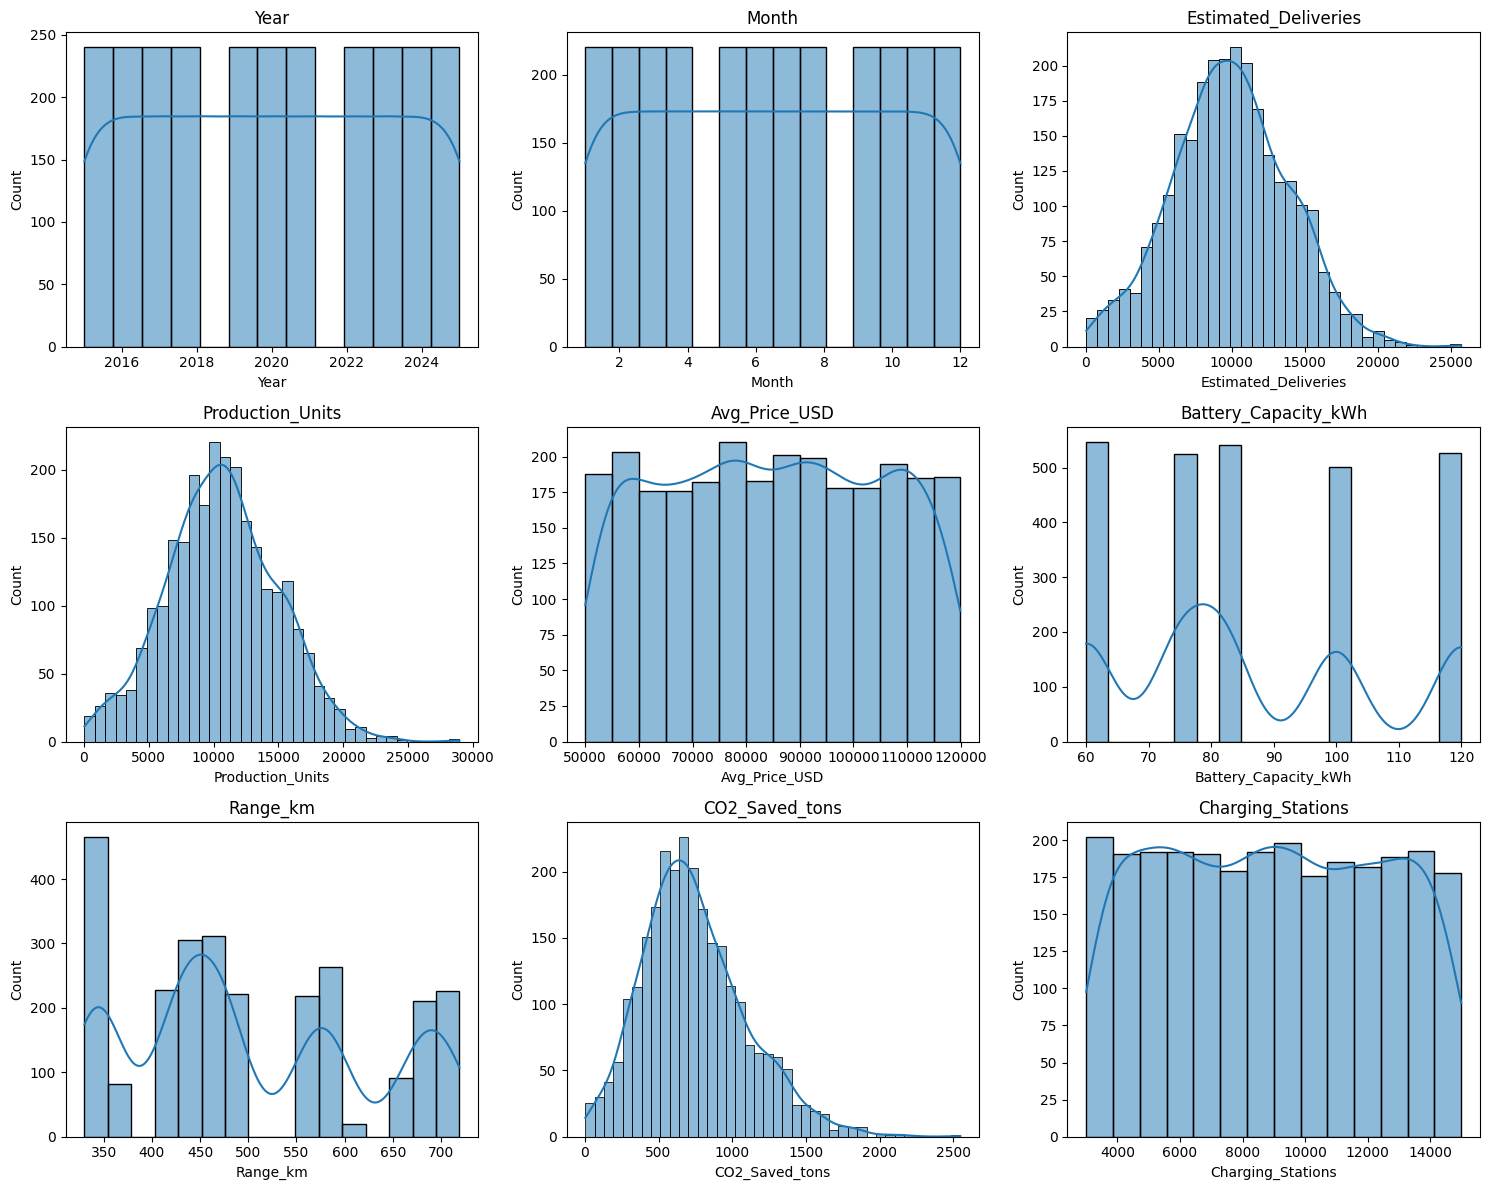

In [21]:
num_cols=df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(df[col], kde=True, ax=axes[i])
  axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations


*   Estimated_Deliveries and Production_Units are approximately normally distributed.
*   Battery capacity and range contain discrete vehicle configurations.
*   CO2 saved is positively skewed.
*   The dataset is well distributed across years and months.





3.2 Correlation Analysis

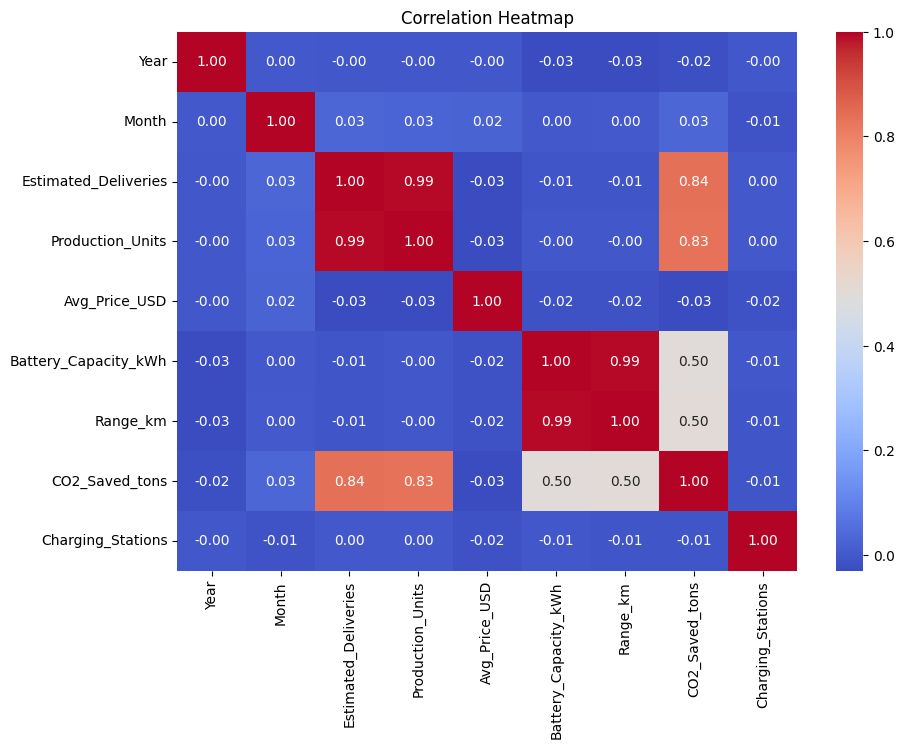

In [22]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

Observations


*   Estimated_Deliveries and Production_Units show a very strong positive correlation (0.99).
*   CO2_Saved_tons is strongly correlated with both deliveries and production units.
*   Battery_Capacity_kWh and Range_km are highly correlated (0.99).
*   Year, Month, and Charging_Stations show weak correlations with most variables.



3.3 Estimated Deliveries by Region

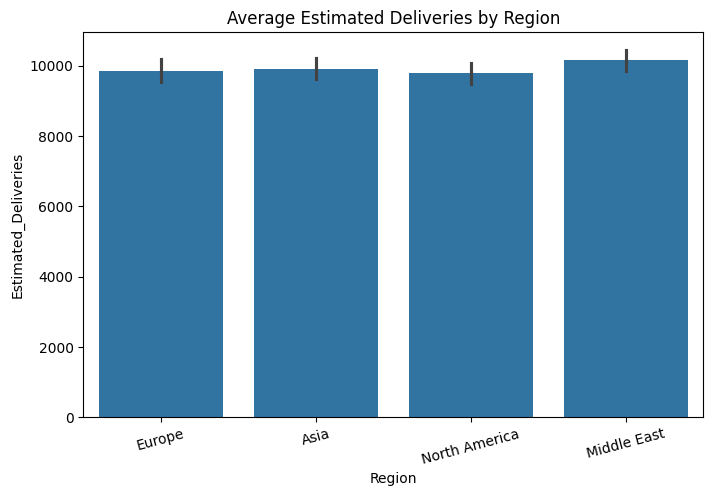

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    estimator='mean'
)

plt.title("Average Estimated Deliveries by Region")
plt.xticks(rotation=15)
plt.show()

Observations


*   Average estimated deliveries are similar across all regions.
*   Middle East shows slightly higher average deliveries compared to other regions.



3.4 Estimated Deliveries by Tesla Model

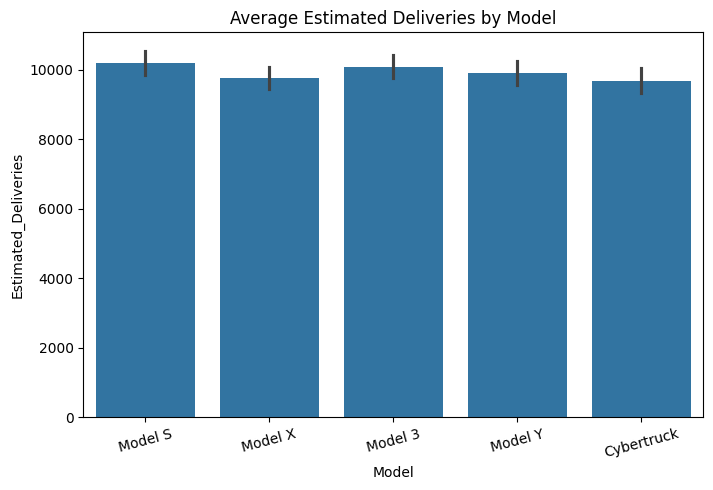

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries',
    estimator='mean'
)
plt.title("Average Estimated Deliveries by Model")
plt.xticks(rotation=15)
plt.show()

Observations


*   Model S and Model 3 show the highest average estimated deliveries.
*   Cybertruck has the lowest average deliveries among the Tesla models.
*   The average deliveries across all models are relatively similar , indicating a balanced dataset.





3.5 Relationship Between Production and Deliveries

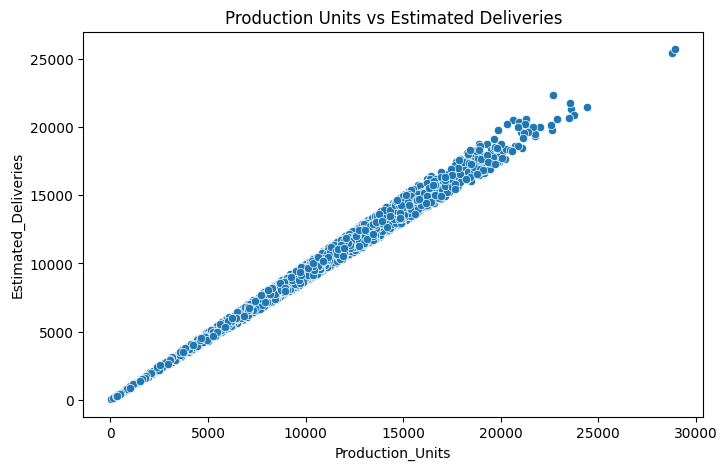

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)
plt.title("Production Units vs Estimated Deliveries")
plt.show()

Observations


*   Production_Units and Estimated_Deliveries exhibit a very strong positive linear relationships.
*   As production increases, estimated deliveries also increase proportionally.
*   Production_Units is likely to be one of the most important predictors for regression modeling.





3.6 Year-wise Delivery Trend

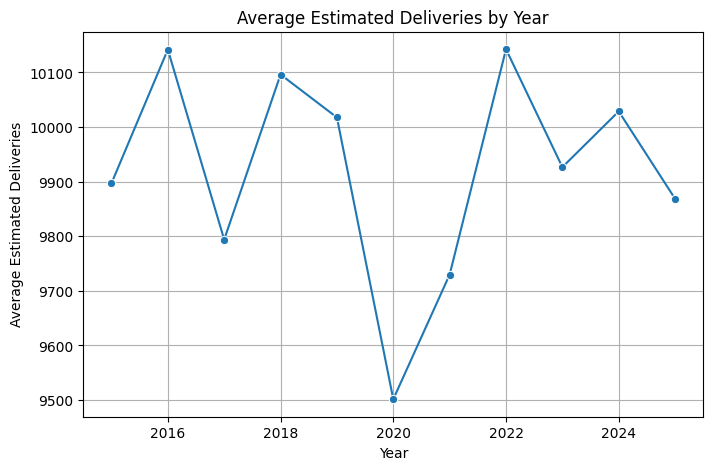

In [26]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].mean()
plt.figure(figsize=(8,5))
sns.lineplot(
    x=yearly_deliveries.index,
    y=yearly_deliveries.values,
    marker='o')
plt.title("Average Estimated Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Average Estimated Deliveries")
plt.grid(True)

plt.show()

Observations



*    Average estimated deliveries remain relatively stable across the years .
*   A noticeable dip is observed in 2020, followed by a recovery in subsequent years.
*   No strong long-term upward or downward trend is visible in the dataset.
*   The temporal nature of the data makes it suitable for the time series forecasting.











3.7 Monthly Delivered Trend

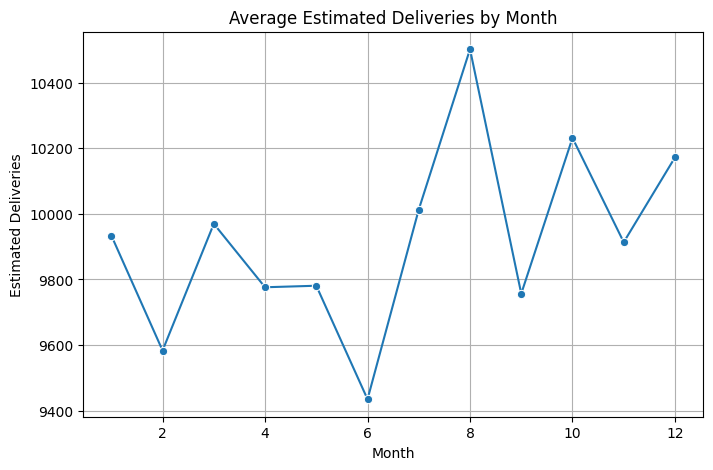

In [27]:
monthly_deliveries = df.groupby('Month')['Estimated_Deliveries'].mean()
plt.figure(figsize=(8,5))
sns.lineplot(
    x=monthly_deliveries.index,
    y=monthly_deliveries.values,
    marker='o'
)
plt.title("Average Estimated Deliveries by Month")
plt.xlabel("Month")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

Observations


*   Average estimated deliveries vary across months, indicating seasonal fluctuations.
*   Month 8 records the highest average deliveries, while Month 6 shows the lowest.
*   Monthly variations suggest that seasonality may influence delivery patterns.
*   Monthly trends can be useful for time series forecasting.





Step 4 : Data Preprocessing

*   Preparing the dataset for machine learning by encoding categorical features, preventing data leakage, and creating training and testing datasets.



Target = Estimated_Deliveries

4.1 Feature Selection

In [28]:
df_ml = df.copy()
X = df_ml.drop('Estimated_Deliveries', axis=1)
y = df_ml['Estimated_Deliveries']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 11)
Target Shape: (2640,)


4.2 Encoding Categorical Variables

In [29]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df_ml.copy()
label_encoders = {}
for col in ['Region', 'Model', 'Source_Type']:
  le = LabelEncoder()
  df_encoded[col] = le.fit_transform(df_encoded[col])
  label_encoders[col] = le
df_encoded.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


Obsrvations


*   Region, Model, and Source_Type were successfully converted into numerical values.
*   Label Encoding enables machine learning algorithms to process categorical variables.
*   The dataset is now ready for train-test splitting and feature scaling .





4.3 Train-Test-Split

In [30]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Estimated_Deliveries', axis=1)
y = df_encoded['Estimated_Deliveries']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 11)
Testing Shape: (528, 11)


Observations


*   The dataset was split into training and testing sets using an 80:20 ratio.
*   The training set contains 2112 observations, while the testing set contains 528 observations.
*   Seperating the test set before scaling helps prevent data leakage.





4.4 Feature Scaling



In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed successfully")
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaling completed successfully
Scaled Training Data Shape: (2112, 11)
Scaled Testing Data Shape: (528, 11)


Observations


*   Feature Scaling was performed using StandardScaler
*   Training data was fitted and transformed, while testing data was only transformed.
*   This approach prevents data leakage and ensures fair model evaluation.






Step 5 : Feature Engineering

*   Create additional informative features that may improve model perfomance and capture relationships, between production, infrastructure, pricing and vehicle specifications.



5.1 Feature Creation

In [32]:
df_fe = df_encoded.copy()
df_fe['Delivery_Production_Ratio'] = (
    df_fe['Estimated_Deliveries'] /
    df_fe['Production_Units']
    )
#Infrastructure support
df_fe['Stations_Per_Delivery'] = (
    df_fe['Charging_Stations'] /
    df_fe['Estimated_Deliveries']
    )
df_fe['Perfomance_Index'] = (
    df_fe['Battery_Capacity_kWh'] *
    df_fe['Range_km']
)
df_fe['CO2_per_Delivery'] = (
    df_fe['CO2_Saved_tons'] /
    df_fe['Estimated_Deliveries']
)
df_fe.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Production_Ratio,Stations_Per_Delivery,Perfomance_Index,CO2_per_Delivery
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,0.691772,84480,0.105600
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,2.012115,32850,0.065699
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,1.672928,39360,0.072000
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,1.423799,85440,0.106799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,0.704865,79320,0.099150


5.2 Final Feature Set for Modeling

In [33]:
df_model = df_fe.drop(
    columns=[
        'Estimated_Deliveries',
        'Delivery_Production_Ratio',
        'Stations_Per_Delivery',
        'CO2_per_Delivery'
    ]
)
df_model.head()

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Perfomance_Index
0,2023,5,1,2,17922,92874.27,120,704,1863.42,1,12207,84480
1,2015,2,0,3,4164,62205.65,75,438,249.46,2,7640,32850
2,2019,1,3,3,9189,117887.32,82,480,605.59,1,14071,39360
3,2021,2,3,1,7311,89294.91,120,712,700.07,2,9333,85440
4,2016,12,2,4,13537,114846.78,120,661,1226.88,0,8722,79320


Step 6 : Regression Modeling

6.1 Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression Metrics:")
print("Mean Absolute Error:", round(mae_lr,2))
print("Root Mean Squared Error:", round(rmse_lr,2))
print("R-squared:", round(r2_lr,4))


Linear Regression Metrics:
Mean Absolute Error: 310.13
Root Mean Squared Error: 383.58
R-squared: 0.9901


#Observations


*   The Linear Regression model achieved an R2 score of 0.9901, indicating that approximately 99.01% of the variance in estimated deliveries is explained by the model.
*   The low MAE and RMSE values suggest strong predictive perfomance with relatively small predictive errors.





6.2 : Ridge Regression

In [35]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print("Ridge Regression Metrics:")
print("Mean Absolute Error:", round(mae_ridge,2))
print("Root Mean Squared Error:", round(rmse_ridge,2))
print("R-squared:", round(r2_ridge,4))


Ridge Regression Metrics:
Mean Absolute Error: 309.91
Root Mean Squared Error: 383.61
R-squared: 0.9901


Observations:


*   Ridge Regression achieved perfomance very similar to Linear Regression.
*   The model model maintained a high R2 score of 0.9901 while applying L2 regularization.
*   Regularization did not significantly improve perfomance, suggesting limited overfitting in the baseline model.





6.3 : Lasso Regression

In [36]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
print("Lasso Regression Metrics:")
print("Mean Absolute Error:", round(mae_lasso,2))
print("Root Mean Squared Error:", round(rmse_lasso,2))
print("R-squared:", round(r2_lasso,4))

Lasso Regression Metrics:
Mean Absolute Error: 310.09
Root Mean Squared Error: 383.45
R-squared: 0.9901


Observations


*   Lasso Regression achieved perfomance comparable to Linear and Ridge Regression.
*   The model maintained an R2 score of 0.9901 while applying L1 regularization.
*   Similar perfomance across all three linear models indicates strong relationships with the dataset.





6.4 Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regression Metrics:")
print("Mean Absolute Error:", round(mae_rf,2))
print("Root Mean Squared Error:", round(rmse_rf,2))
print("R-squared:", round(r2_rf,4))

Random Forest Regression Metrics:
Mean Absolute Error: 323.46
Root Mean Squared Error: 409.5
R-squared: 0.9888


  Observations:

*   Random forest achieved an R2 score of 0.9888, which is slightly lower than linear models.
*   The model produced higher MAE and RMSE values compared to Linear, Ridge, and Lasso Regression.
*   This suggests that the relationship between features and estimated deliveries is predominantly linear.
*   For this dataset, linear models outperform the ensemble model while maintaining simpler interpretability.





Step 7 : Cross Validation

*   Cross Validation is performed to evaluate model stability and generalization perfomance across different data splits.



In [38]:
from sklearn.model_selection import cross_val_score
cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')
print("Cross Validation R2 scores:")
print(cv_lr)
print("\nAverage CV R2:", round(cv_lr.mean(),4))
print("Standard Deviation:", round(cv_lr.std(),4))

Cross Validation R2 scores:
[0.99064078 0.99054527 0.99007003 0.98953668 0.99057914]

Average CV R2: 0.9903
Standard Deviation: 0.0004


Observations


*   Five-Fold cross validation produced consistently high R2 scores across all folds.
*   The average cross-validation R2 score of 0.9903 confirms excellent predictive perfomance.
*   The very low standard deviation (0.0004) indicates strong model stability and robustness.
*   These results suggest that the model generalizes well and is unlikely to suffer from significant overfitting.





Step 8 : Hyperparameter Tuning

*   Grid SearchCv is used to identify the optimal hyperparameters for Ridge Regression.


In [39]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
print("Best Parameters:", ridge_cv.best_params_)
print("Best Score:", round(ridge_cv.best_score_, 4))

Best Parameters: {'alpha': 0.1}
Best Score: 0.9903


Hyperparametr Tuning Observations :

*   GridSearchCV was used to evaluate multiple values of the Ridge regularization parameter.
*   The best parameter was selected based on cross-validation perfomance.
*   Hyperparameter tuning helps identify the most effective model perfomance.




Step 9 : Time Series Analysis

*   Analyze Tesla delivery trends over time and prepare the dataset for forecasting.



9.1 Create Date Feature

In [40]:
df_ts = df.copy()
df_ts['Date'] = pd.to_datetime(
  df_ts['Year'].astype(str) + '-' +
  df_ts['Month'].astype(str) + '-01'
)
df_ts = df_ts.sort_values('Date')
df_ts[['Date', 'Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
872,2015-01-01,12446
2354,2015-01-01,11446
2312,2015-01-01,8803
2293,2015-01-01,6367
2215,2015-01-01,8795


Observations


*   A Date feature was created by combining the Year and Month columns.
*   The dataset was sorted chronologically to support time series analysis.
*   Multiple records may exist for the same month because deliveries are reported across different regions and vehicle models.






9.2 Delivery Trend Over Time


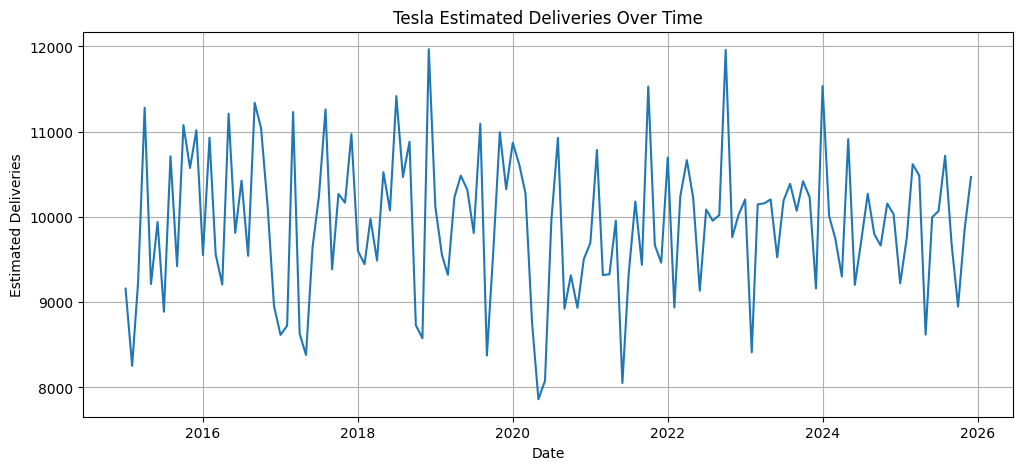

In [41]:
monthly_ts = df_ts.groupby('Date')['Estimated_Deliveries'].mean()
plt.figure(figsize=(12,5))
plt.plot(monthly_ts.index,monthly_ts.values)
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

Observations


*   Estimated deliveries fluctuate throughout the period from 2015 to 2025.
*   No strong long-term upward or downward trend is clearly visible.
*   Several peaks and dips indicate seasonal or random variations in monthly deliveries.
*   further statistical testing is required to determine whether the series is stationary.





Step 10 : Stationarity Testing

*   Determine whether the delivery time series is stationary using the Augmented Dickey-Fuller (ADF) test.



In [42]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_ts)
print("ADF Statistice:", result[0])
print("p-value:", result[1])
print("Critical Values:")
if result[1] < 0.05:
  print("Series is Stationary")
else:
  print("Series is Non-Stationary")

ADF Statistice: -8.880990349502973
p-value: 1.3181396968145779e-14
Critical Values:
Series is Stationary


Stationarity Observations


*   The Augmented Dickey-Fuller (ADF) test produced a p-value significantly below 0.05.
*   Therefore, the null hypothesis of non-stationarity is rejected.
*   The delivery time series can be considered stationary and suitable for time series forecasting analysis.
*   Stationarity indicates that the statistical properties of the series remain relatively stable over time.




Step 11 : Lag Features and Rolling Statistics

In [43]:
ts_features = monthly_ts.to_frame()
ts_features['lag_1'] = ts_features['Estimated_Deliveries'].shift(1)
ts_features['lag_3'] = ts_features['Estimated_Deliveries'].shift(3)
ts_features.head()

,Estimated_Deliveries,lag_1,lag_3
Date,,,
2015-01-01,9159.00,NaN,NaN
2015-02-01,8252.65,9159.00,NaN
2015-03-01,9228.35,8252.65,NaN
2015-04-01,11281.15,9228.35,9159.00
2015-05-01,9213.20,11281.15,8252.65


Lag Features Observations

*   Lag features use previous observations to predict future values.
*   Lag_1 represents the previous month's deliveries.
*   Lag_3 represents deliveries from three months earlier.





11.2 Rolling Statistics

In [44]:
ts_features['Rolling_Mean_3'] = (
    ts_features['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
ts_features['Rolling_Std__#'] = (
    ts_features['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)
ts_features.head()

,Estimated_Deliveries,lag_1,lag_3,Rolling_Mean_3,Rolling_Std__#
Date,,,,,
2015-01-01,9159.00,NaN,NaN,NaN,NaN
2015-02-01,8252.65,9159.00,NaN,NaN,NaN
2015-03-01,9228.35,8252.65,NaN,8880.000000,544.406441
2015-04-01,11281.15,9228.35,9159.00,9587.383333,1545.843383
2015-05-01,9213.20,11281.15,8252.65,9907.566667,1189.582179


Rolling Statistics Observations


*   Rolling Mean and Rolling Standard Deviation were computed using a 3-month window.
*   The rolling mean smooths short-term fluctuations and highlights underlying patterns.
*   Rolling Standard deviation measures recent variability in deliveries.





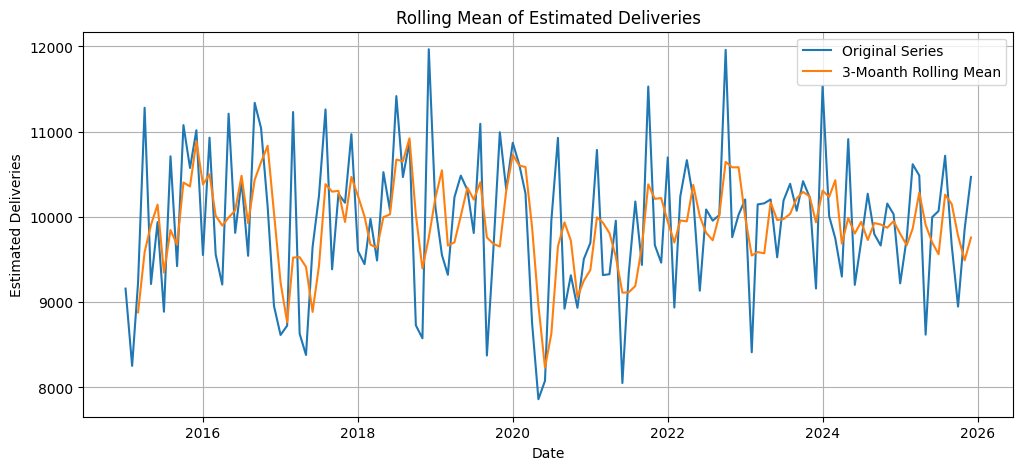

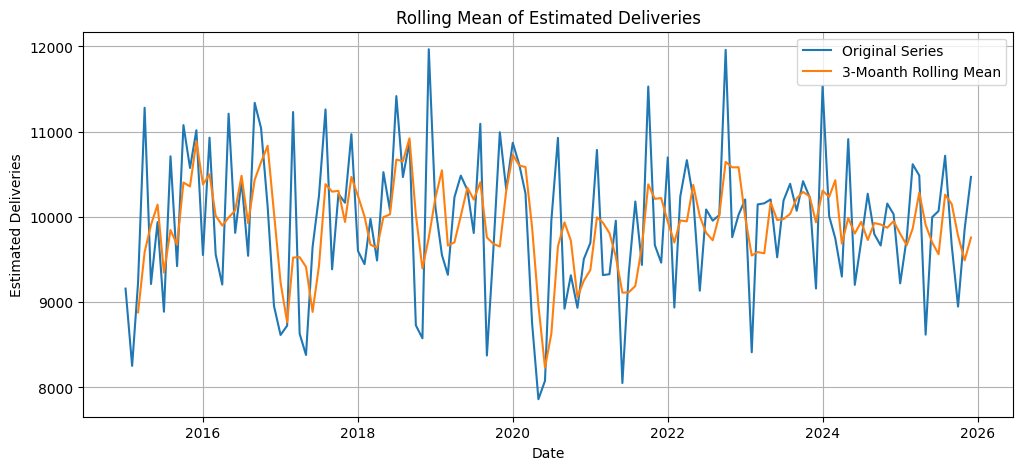

In [46]:
plt.figure(figsize=(12,5))
plt.plot(
    ts_features.index,
    ts_features['Estimated_Deliveries'],
    label='Original Series'
)
plt.plot(
    ts_features.index,
    ts_features['Rolling_Mean_3'],
    label='3-Moanth Rolling Mean'
)
plt.title("Rolling Mean of Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()

Observations


*   The 3-month rolling mean ammoths short-term fluctuations in estimated deliveries.
*   The rolling trend remains relatively stable through out the study period.



Step 12 : Forecasting

In [47]:
forecast_df = ts_features.copy()
forecast_df = forecast_df.dropna()
forecast_df.head()

,Estimated_Deliveries,lag_1,lag_3,Rolling_Mean_3,Rolling_Std__#
Date,,,,,
2015-04-01,11281.15,9228.35,9159.00,9587.383333,1545.843383
2015-05-01,9213.20,11281.15,8252.65,9907.566667,1189.582179
2015-06-01,9939.35,9213.20,9228.35,10144.566667,1049.137603
2015-07-01,8887.95,9939.35,11281.15,9346.833333,538.287926
2015-08-01,10711.15,8887.95,9213.20,9846.150000,915.166236


12.2 Chronological Train-Test Split

In [55]:
train_size = int(len(forecast_df) * 0.8)
train = forecast_df.iloc[:train_size]
test = forecast_df.iloc[train_size:]
X_train_ts = train[
    ['lag_1', 'lag_3', 'Rolling_Mean_3', 'Rolling_Std__#']
]
y_train_ts = train['Estimated_Deliveries']
X_test_ts = test[
    ['lag_1', 'lag_3', 'Rolling_Mean_3', 'Rolling_Std__#']
]
y_test_ts = test['Estimated_Deliveries']
print("Train Size", train.shape)
print("Test Size", test.shape)

Train Size (103, 5)
Test Size (26, 5)


12,3 Forecasting Model

In [58]:
from sklearn.ensemble import RandomForestRegressor
forecast_model = RandomForestRegressor(n_estimators=100, random_state=42)
forecast_model.fit(X_train_ts, y_train_ts)
forecast_pred = forecast_model.predict(X_test_ts)

12.4 Forecast Evaluation

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
forecast_mae = mean_absolute_error(y_test_ts, forecast_pred)
forecast_rmse = np.sqrt(mean_squared_error(y_test_ts, forecast_pred))
forecast_r2 = r2_score(y_test_ts, forecast_pred)
print("Forecast Metrics:")
print("Mean Absolute Error:", round(forecast_mae,2))
print("Root Mean Squared Error:", round(forecast_rmse,2))
print("R-squared:", round(forecast_r2,4))


Forecast Metrics:
Mean Absolute Error: 469.63
Root Mean Squared Error: 593.4
R-squared: 0.1292


Forecast Visualization

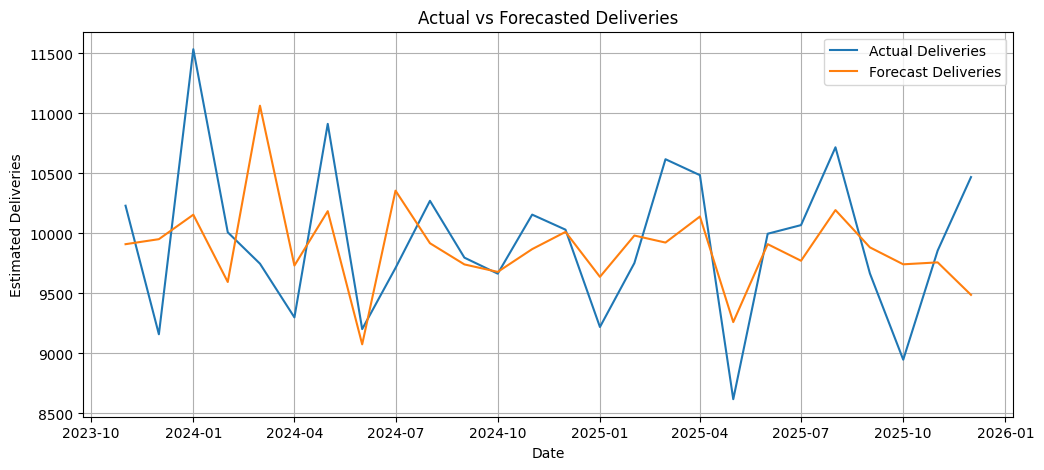

In [60]:
plt.figure(figsize=(12,5))
plt.plot(test.index, y_test_ts, label='Actual Deliveries')
plt.plot(test.index, forecast_pred, label='Forecast Deliveries')
plt.title("Actual vs Forecasted Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()

Observations


*   The forecasted values generally follow the actual delivery trend.
*   Some differences exist during sudden peaks and drops in deliverries.
*   Forecasting is more challenging than regression because it relies only on past delivery patterns
*   Overall, the model captures the general delivery behaviour over time.





Step 13 : Model Comparision

In [62]:
comparision = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'Forecast Model'],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_rf, forecast_mae],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, forecast_rmse],
    'R2': [r2_lr, r2_ridge, r2_lasso, r2_rf, forecast_r2]
})
comparision = comparision.sort_values(by='R2', ascending=False)
comparision

,Model,MAE,RMSE,R2
2,Lasso Regression,310.087089,383.452106,0.990136
0,Linear Regression,310.130022,383.576570,0.990130
1,Ridge Regression,309.908833,383.608542,0.990128
3,Random Forest,323.460114,409.496025,0.988751
4,Forecast Model,469.625635,593.398983,0.129177


Model Comparision Observations


*   Linear Regression, Ridge Regression, and Lasso Regression achieved the highest perfomance with R2 scores close to 0.99.
*   Random Forest performed slightly lower than the linear models.
*   The Forecasting Model achieved lower accuracy because it relied only on historical delivery.
*   Overall, Linear Regression emerged as the best-performing model for this dataset.




Final Conclusion





1.   An end-to-end ML pipeline was successfully developed for Tesla delivery data, covering preprocessing, EDA, Feature engineering, regression modeling, and forecasting.
2.   Lasso Regression achieved the best perfomance with an R2 score of 0.9901, demonstrating excellent predictive capability.



